# Análisis de Base de Datos CostaDelInkaDB usando CRISP-DM

Este notebook sigue la metodología CRISP-DM (Cross-Industry Standard Process for Data Mining) para analizar la base de datos del Hotel Costa del Inka.

## Índice
1. Comprensión del Negocio
   - Objetivos del Negocio
   - Evaluación de la Situación
   - Objetivos de la Minería de Datos
2. Comprensión de los Datos
   - Recolección de Datos Iniciales
   - Descripción de los Datos
   - Exploración de los Datos
   - Verificación de la Calidad de los Datos


In [1]:
# Importación de librerías necesarias
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pprint

# Configuración de visualización
sns.set_palette('husl')
pd.set_option('display.max_columns', None)


# 1. Comprensión del Negocio

## 1.1 Objetivos del Negocio

El Hotel Costa del Inka busca optimizar sus operaciones y mejorar la experiencia del cliente. Los objetivos principales incluyen:

- Maximizar la ocupación del hotel
- Reducir las cancelaciones de reservas
- Optimizar los precios (ADR - Average Daily Rate)
- Mejorar la satisfacción del cliente

## 1.2 Evaluación de la Situación

### Recursos Disponibles
- Base de datos MongoDB con información detallada de:
  - Clientes
  - Reservas
  - Detalles de Reservas
  - Pagos
  - Catálogos (Tipos de Habitación, Tipos de Cliente, etc.)

### Requisitos, Supuestos y Restricciones
- Los datos están almacenados en MongoDB
- Se requiere análisis de patrones históricos
- Se debe mantener la privacidad de los datos sensibles de clientes

## 1.3 Objetivos de la Minería de Datos

1. Identificar patrones en las reservas y cancelaciones
2. Analizar el comportamiento de los clientes
3. Determinar factores que influyen en el ADR
4. Segmentar clientes según su comportamiento


# 2. Comprensión de los Datos

## 2.1 Recolección de Datos Iniciales


In [2]:
# Conexión a MongoDB
try:
    client = MongoClient('mongodb://localhost:27017/')
    db = client['CostaDelInkaDB']
    print('Conexión exitosa a MongoDB')
    print('\nColecciones disponibles:')
    for collection in db.list_collection_names():
        count = db[collection].count_documents({})
        print(f'- {collection}: {count} documentos')
except Exception as e:
    print(f'Error al conectar a MongoDB: {e}')


Conexión exitosa a MongoDB

Colecciones disponibles:
- Reservas: 15581 documentos
- TiposDocumentoPago: 0 documentos
- Clientes: 12440 documentos
- Pagos: 0 documentos
- ModalidadesPago: 0 documentos
- TiposHabitacion: 10 documentos
- TiposCliente: 0 documentos
- DetallesReserva: 15582 documentos


## 2.2 Descripción de los Datos

A continuación, analizaremos la estructura de cada colección principal para entender mejor los datos disponibles.


In [3]:
def mostrar_estructura_coleccion(nombre_coleccion):
    """Muestra la estructura y un ejemplo de documento de una colección."""
    print(f'\n=== {nombre_coleccion} ===')
    # Obtener un documento de ejemplo
    doc = db[nombre_coleccion].find_one()
    if doc:
        print('\nEstructura del documento:')
        for campo, valor in doc.items():
            print(f'- {campo}: {type(valor).__name__}')
        print('\nEjemplo de documento:')
        pprint.pprint(doc)
    else:
        print('No hay documentos en esta colección')

colecciones_principales = ['Clientes', 'Reservas', 'DetallesReserva', 'Pagos']
for col in colecciones_principales:
    mostrar_estructura_coleccion(col)



=== Clientes ===

Estructura del documento:
- _id: ObjectId
- nombre_completo: str
- email: str
- telefono: str
- tipo_documento_identidad: str
- numero_documento_identidad: str
- fecha_nacimiento: datetime
- pais_origen_cliente: str
- es_huesped_recurrente_historico: bool
- total_cancelaciones_previas_cliente: int
- total_reservas_previas_no_canceladas_cliente: int
- historial_ids_reservas: list

Ejemplo de documento:
{'_id': ObjectId('6867e63795a6ac6e2299e6e1'),
 'email': 'juliateofilo@example.com',
 'es_huesped_recurrente_historico': False,
 'fecha_nacimiento': datetime.datetime(1982, 4, 22, 0, 0),
 'historial_ids_reservas': [ObjectId('6867e63795a6ac6e2299e6e2')],
 'nombre_completo': 'Cruz de Alba',
 'numero_documento_identidad': 'P6860452',
 'pais_origen_cliente': 'AR',
 'telefono': '+34820 29 42 01',
 'tipo_documento_identidad': 'Pasaporte',
 'total_cancelaciones_previas_cliente': 0,
 'total_reservas_previas_no_canceladas_cliente': 0}

=== Reservas ===

Estructura del documento:


## 2.3 Exploración de los Datos

### 2.3.1 Análisis de Clientes
Analizaremos la distribución de clientes por país, proporción de clientes recurrentes y otros patrones relevantes.


Distribución de clientes por país de origen:


,_id,total_clientes,clientes_recurrentes
0,PE,7716,348
1,AR,1281,15
2,CO,1130,8
3,EC,939,9
4,BO,735,2
5,CL,388,6
6,BR,207,1
7,,44,0


<Figure size 1200x600 with 0 Axes>

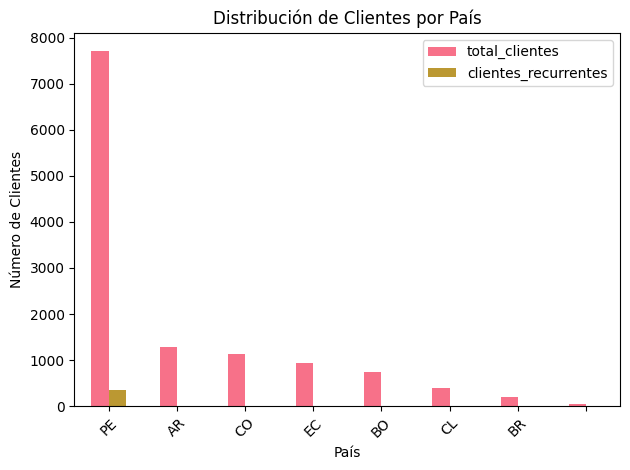


Estadísticas generales:
Total de clientes: 12440
Clientes recurrentes: 389 (3.13%)


In [4]:
def analizar_clientes():
    """Análisis exploratorio de la colección Clientes"""
    # Análisis por país y clientes recurrentes
    pipeline = [
        {
            "$group": {
                "_id": "$pais_origen_cliente",
                "total_clientes": {"$sum": 1},
                "clientes_recurrentes": {
                    "$sum": {"$cond": ["$es_huesped_recurrente_historico", 1, 0]}
                }
            }
        },
        {"$sort": {"total_clientes": -1}}
    ]
    
    resultados = list(db.Clientes.aggregate(pipeline))
    df_clientes = pd.DataFrame(resultados)
    
    if not df_clientes.empty:
        print("Distribución de clientes por país de origen:")
        display(df_clientes)
        
        # Visualización
        plt.figure(figsize=(12, 6))
        df_clientes.plot(kind='bar', x='_id', y=['total_clientes', 'clientes_recurrentes'])
        plt.title('Distribución de Clientes por País')
        plt.xlabel('País')
        plt.ylabel('Número de Clientes')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Estadísticas adicionales
        total_clientes = df_clientes['total_clientes'].sum()
        total_recurrentes = df_clientes['clientes_recurrentes'].sum()
        print(f"\nEstadísticas generales:")
        print(f"Total de clientes: {total_clientes}")
        print(f"Clientes recurrentes: {total_recurrentes} ({(total_recurrentes/total_clientes)*100:.2f}%)")
    else:
        print("No hay datos de clientes para analizar")

analizar_clientes()


### 2.3.2 Análisis de Reservas
Exploraremos los patrones de reservas, incluyendo estados de reserva, ADR (Average Daily Rate) y duración de estadías.


Estadísticas de reservas por estado:


,_id,total,adr_promedio,noches_promedio
0,Salida,10479,101.051491,3.410822
1,Cancelada,4959,105.873555,3.431135
2,No-Show,143,95.254196,3.538462


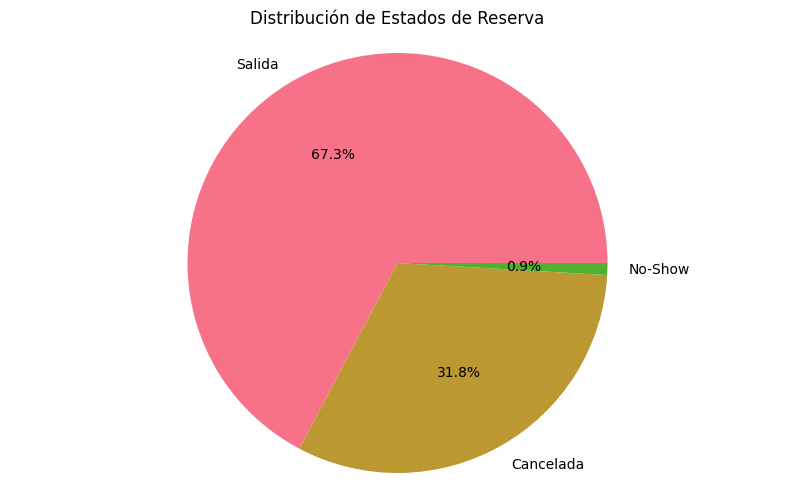

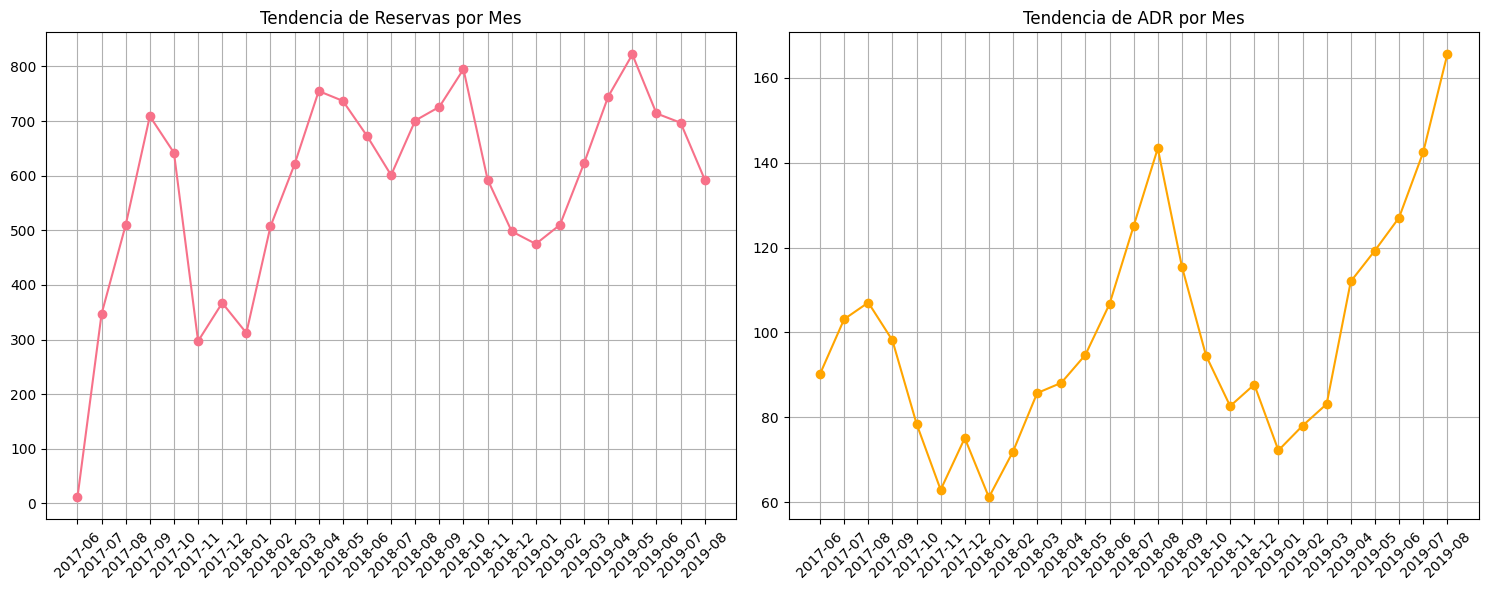

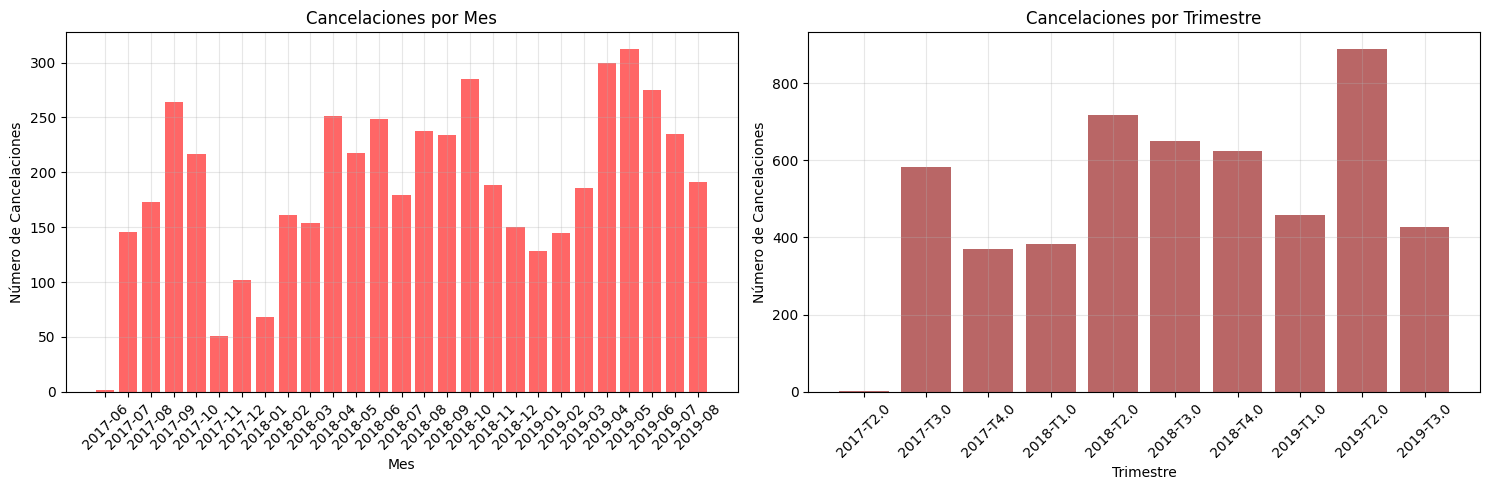


Estadísticas de Cancelaciones por Trimestre:


,Trimestre,Total Reservas,Cancelaciones,Tasa de Cancelación (%)
0,2017-T2.0,11,2,18.18
1,2017-T3.0,1566,583,37.23
2,2017-T4.0,1306,370,28.33
3,2018-T1.0,1440,383,26.60
4,2018-T2.0,2165,718,33.16
5,2018-T3.0,2028,651,32.10
6,2018-T4.0,1886,623,33.03
7,2019-T1.0,1608,459,28.54
8,2019-T2.0,2281,887,38.89
9,2019-T3.0,1290,426,33.02


In [5]:
def analizar_reservas():
    """Análisis exploratorio de la colección Reservas"""
    # Estadísticas de reservas por estado
    pipeline_estados = [
        {"$group": {
            "_id": "$estado_reserva",
            "total": {"$sum": 1},
            "adr_promedio": {"$avg": "$adr"},
            "noches_promedio": {"$avg": "$noches_estadia"}
        }},
        {"$sort": {"total": -1}}
    ]
    
    resultados = list(db.Reservas.aggregate(pipeline_estados))
    df_reservas = pd.DataFrame(resultados)
    
    if not df_reservas.empty:
        print("Estadísticas de reservas por estado:")
        display(df_reservas)
        
        # Visualización de estados de reserva
        plt.figure(figsize=(10, 6))
        plt.pie(df_reservas['total'], labels=df_reservas['_id'], autopct='%1.1f%%')
        plt.title('Distribución de Estados de Reserva')
        plt.axis('equal')
        plt.show()
        
        # Análisis temporal de reservas y cancelaciones
        pipeline_temporal = [
            {"$group": {
                "_id": {
                    "año": {"$year": "$fecha_llegada"},
                    "mes": {"$month": "$fecha_llegada"},
                    "trimestre": {"$ceil": {"$divide": [{"$month": "$fecha_llegada"}, 3]}}
                },
                "total_reservas": {"$sum": 1},
                "cancelaciones": {"$sum": {"$cond": ["$fue_cancelada", 1, 0]}},
                "adr_promedio": {"$avg": "$adr"}
            }},
            {"$sort": {"_id.año": 1, "_id.mes": 1}}
        ]
        
        resultados_temporal = list(db.Reservas.aggregate(pipeline_temporal))
        df_temporal = pd.DataFrame(resultados_temporal)
        
        if not df_temporal.empty:
            # Crear etiquetas de fecha
            df_temporal['fecha'] = df_temporal['_id'].apply(
                lambda x: f"{x['año']}-{x['mes']:02d}")
            df_temporal['fecha_trimestre'] = df_temporal['_id'].apply(
                lambda x: f"{x['año']}-T{x['trimestre']}")
            
            # Gráfico de tendencia temporal de reservas y ADR
            plt.figure(figsize=(15, 6))
            plt.subplot(1, 2, 1)
            plt.plot(df_temporal['fecha'], df_temporal['total_reservas'], marker='o')
            plt.title('Tendencia de Reservas por Mes')
            plt.xticks(rotation=45)
            plt.grid(True)
            
            plt.subplot(1, 2, 2)
            plt.plot(df_temporal['fecha'], df_temporal['adr_promedio'], marker='o', color='orange')
            plt.title('Tendencia de ADR por Mes')
            plt.xticks(rotation=45)
            plt.grid(True)
            plt.tight_layout()
            plt.show()
            
            # Análisis de cancelaciones
            # 1. Cancelaciones mensuales
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 2, 1)
            plt.bar(df_temporal['fecha'], df_temporal['cancelaciones'], color='red', alpha=0.6)
            plt.title('Cancelaciones por Mes')
            plt.xlabel('Mes')
            plt.ylabel('Número de Cancelaciones')
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            
            # 2. Cancelaciones trimestrales (agregadas)
            df_trimestral = df_temporal.groupby('fecha_trimestre').agg({
                'cancelaciones': 'sum',
                'total_reservas': 'sum'
            }).reset_index()
            
            df_trimestral['tasa_cancelacion'] = (df_trimestral['cancelaciones'] / df_trimestral['total_reservas'] * 100)
            
            plt.subplot(1, 2, 2)
            plt.bar(df_trimestral['fecha_trimestre'], df_trimestral['cancelaciones'], color='darkred', alpha=0.6)
            plt.title('Cancelaciones por Trimestre')
            plt.xlabel('Trimestre')
            plt.ylabel('Número de Cancelaciones')
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Mostrar estadísticas de cancelaciones
            print("\nEstadísticas de Cancelaciones por Trimestre:")
            df_stats = pd.DataFrame({
                'Trimestre': df_trimestral['fecha_trimestre'],
                'Total Reservas': df_trimestral['total_reservas'],
                'Cancelaciones': df_trimestral['cancelaciones'],
                'Tasa de Cancelación (%)': df_trimestral['tasa_cancelacion'].round(2)
            })
            display(df_stats)
    else:
        print("No hay datos de reservas para analizar")

analizar_reservas()


### 2.3.3 Análisis de Detalles de Reserva
Analizaremos los tipos de habitación más reservados y los patrones de cambios en las reservas.


Estadísticas por tipo de habitación:


,_id,total_reservas,promedio_cambios,huespedes_recurrentes
0,A,11142,0.206247,407
1,D,2572,0.213064,51
2,E,855,0.304094,27
3,F,386,0.388601,6
4,G,265,0.305660,7
5,B,152,0.559211,0
6,C,135,0.533333,4
7,H,73,0.315068,1
8,L,2,0.000000,0


<Figure size 1200x600 with 0 Axes>

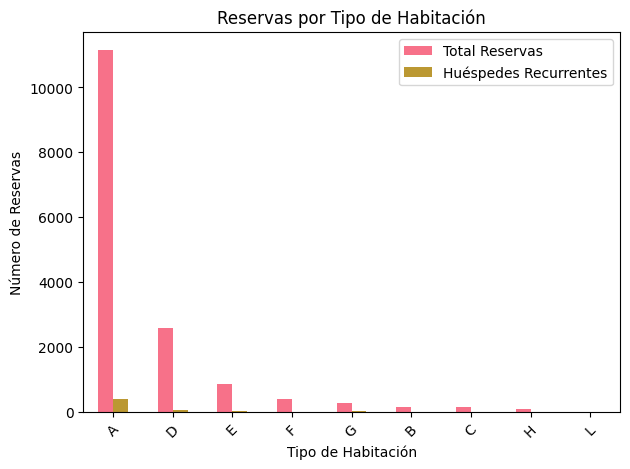

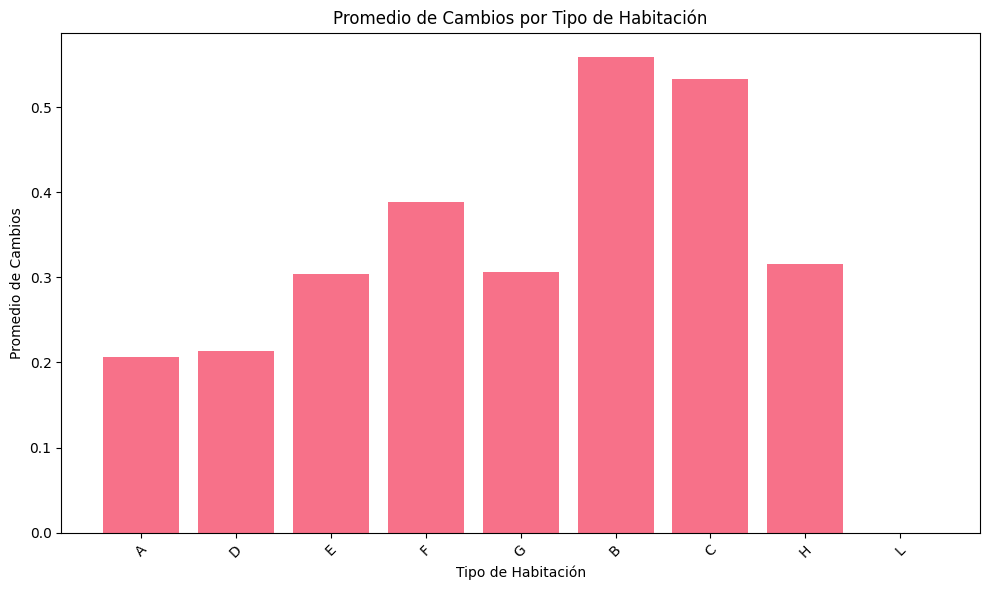

In [6]:
def analizar_detalles_reserva():
    """Análisis exploratorio de la colección DetallesReserva"""
    pipeline = [
        {"$group": {
            "_id": "$tipo_habitacion_reservada",
            "total_reservas": {"$sum": 1},
            "promedio_cambios": {"$avg": "$cambios_en_reserva"},
            "huespedes_recurrentes": {
                "$sum": {"$cond": ["$es_huesped_recurrente_al_reservar", 1, 0]}
            }
        }},
        {"$sort": {"total_reservas": -1}}
    ]
    
    resultados = list(db.DetallesReserva.aggregate(pipeline))
    df_detalles = pd.DataFrame(resultados)
    
    if not df_detalles.empty:
        print("Estadísticas por tipo de habitación:")
        display(df_detalles)
        
        # Visualización de distribución de tipos de habitación
        plt.figure(figsize=(12, 6))
        df_detalles.plot(kind='bar', x='_id', y=['total_reservas', 'huespedes_recurrentes'])
        plt.title('Reservas por Tipo de Habitación')
        plt.xlabel('Tipo de Habitación')
        plt.ylabel('Número de Reservas')
        plt.xticks(rotation=45)
        plt.legend(['Total Reservas', 'Huéspedes Recurrentes'])
        plt.tight_layout()
        plt.show()
        
        # Gráfico de cambios promedio por tipo de habitación
        plt.figure(figsize=(10, 6))
        plt.bar(df_detalles['_id'], df_detalles['promedio_cambios'])
        plt.title('Promedio de Cambios por Tipo de Habitación')
        plt.xlabel('Tipo de Habitación')
        plt.ylabel('Promedio de Cambios')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de detalles de reserva para analizar")

analizar_detalles_reserva()


# Fase 3: Preparación de los Datos (Data Preparation)

En esta fase, prepararemos los datos extraídos de la base de datos `CostaDelInkaDB` en MongoDB para el modelado. Las tareas incluyen:
1.  **Integración de Datos**: Unir las colecciones para crear un dataset plano.
2.  **Selección de Datos**: Elegir las características (features) más relevantes.
3.  **Limpieza de Datos**: Manejar valores nulos y corregir errores.
4.  **Construcción de Datos**: Crear nuevas características (feature engineering).
5.  **Formateo de Datos**: Codificar variables categóricas y escalar las numéricas.

El objetivo final es tener un conjunto de datos `X` (features) e `y` (target) listos para la Fase 4: Modelado.

In [7]:
# --- 1. Importación de Librerías ---
import pandas as pd
import numpy as np
from pymongo import MongoClient
from bson.objectid import ObjectId
import warnings

# Configuraciones de visualización
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# --- 2. Conexión a MongoDB ---
# Reemplaza con tu cadena de conexión si usas MongoDB Atlas
# Ejemplo: "mongodb+srv://<user>:<password>@<cluster-url>/CostaDelInkaDB?retryWrites=true&w=majority"
MONGO_URI = "mongodb://localhost:27017/" 
DB_NAME = "CostaDelInkaDB"

try:
    client = MongoClient(MONGO_URI)
    db = client[DB_NAME]
    # Comprobar la conexión listando las colecciones
    collections = db.list_collection_names()
    print(f"Conexión exitosa a la base de datos '{DB_NAME}'.")
    print(f"Colecciones disponibles: {collections}")
except Exception as e:
    print(f"Error al conectar a la base de datos: {e}")

Conexión exitosa a la base de datos 'CostaDelInkaDB'.
Colecciones disponibles: ['Reservas', 'TiposDocumentoPago', 'Clientes', 'Pagos', 'ModalidadesPago', 'TiposHabitacion', 'TiposCliente', 'DetallesReserva']


### 3.1 Integración y Creación del Conjunto de Datos

Vamos a construir nuestro dataset de modelado uniendo las colecciones. Usaremos un pipeline de agregación en MongoDB para mayor eficiencia.

In [8]:
# Pipeline de agregación para unir las colecciones
# -- VERSIÓN CORREGIDA --
pipeline = [
    {
        '$lookup': {
            'from': 'DetallesReserva',
            'localField': 'detalle_reserva_id',
            'foreignField': '_id',
            'as': 'detalle'
        }
    },
    {
        '$unwind': '$detalle' # Descomponer el array resultante del lookup
    },
    {
        '$lookup': {
            'from': 'Clientes',
            'localField': 'cliente_id',
            'foreignField': '_id',
            'as': 'cliente'
        }
    },
    {
        '$unwind': '$cliente'
    },
    {
        # En la proyección de inclusión, solo especificamos los campos que QUEREMOS.
        # Los campos no mencionados (como cliente_id y detalle_reserva_id) se omiten automáticamente.
        '$project': {
            # --- Campos de la colección Reservas ---
            'fue_cancelada': 1,
            'tiempo_anticipacion_reserva_dias': 1,
            'fecha_llegada': 1,
            'noches_estadia': 1,
            'adr': 1, # Average Daily Rate
            'canal_reserva': 1,
            
            # --- Campos de la colección DetallesReserva ---
            'pais_origen_reserva': '$detalle.pais_origen_reserva',
            'es_huesped_recurrente_al_reservar': '$detalle.es_huesped_recurrente_al_reservar',
            'cancelaciones_previas_cliente_al_reservar': '$detalle.cancelaciones_previas_cliente_al_reservar',
            'reservas_previas_no_canceladas_cliente_al_reservar': '$detalle.reservas_previas_no_canceladas_cliente_al_reservar',
            'tipo_habitacion_reservada': '$detalle.tipo_habitacion_reservada',
            'tipo_habitacion_asignada': '$detalle.tipo_habitacion_asignada',
            'cambios_en_reserva': '$detalle.cambios_en_reserva',
            'tipo_cliente_en_reserva': '$detalle.tipo_cliente_en_reserva',

            # --- Campos de la colección Clientes (si se necesitaran más) ---
            # 'pais_origen_cliente': '$cliente.pais_origen_cliente',

            # --- Exclusión de _id (esto SÍ está permitido) ---
            '_id': 0
        }
    }
]

# Ejecutar el pipeline y cargar en un DataFrame de Pandas
try:
    reservas_cursor = db.Reservas.aggregate(pipeline)
    df_raw = pd.DataFrame(list(reservas_cursor))
    print(f"✅ Se ha creado el DataFrame `df_raw` con {df_raw.shape[0]} registros y {df_raw.shape[1]} columnas.")
except Exception as e:
    print(f"❌ Error durante la agregación: {e}")

# --- VISUALIZACIÓN DEL RESULTADO ---
print("\n--- Primeros 5 registros del DataFrame `df_raw` ---")
display(df_raw.head())

print("\n--- Información general y tipos de datos de `df_raw` ---")
df_raw.info()

✅ Se ha creado el DataFrame `df_raw` con 15581 registros y 14 columnas.

--- Primeros 5 registros del DataFrame `df_raw` ---


,fue_cancelada,tiempo_anticipacion_reserva_dias,fecha_llegada,noches_estadia,adr,canal_reserva,pais_origen_reserva,es_huesped_recurrente_al_reservar,cancelaciones_previas_cliente_al_reservar,reservas_previas_no_canceladas_cliente_al_reservar,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_en_reserva,tipo_cliente_en_reserva
0,False,102,2019-08-07,7,201.4,TA/TO,AR,False,0,0,G,G,0,Transient
1,False,201,2019-04-21,7,71.3,TA/TO,AR,True,0,1,F,F,0,Transient
2,False,2,2019-03-29,1,97.0,Direct,PE,True,0,1,A,A,0,Transient
3,False,25,2018-10-17,3,129.0,TA/TO,PE,False,0,0,A,A,0,Transient
4,False,189,2017-08-10,4,76.5,TA/TO,CL,False,0,0,A,A,0,Transient-Party



--- Información general y tipos de datos de `df_raw` ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15581 entries, 0 to 15580
Data columns (total 14 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   fue_cancelada                                       15581 non-null  bool          
 1   tiempo_anticipacion_reserva_dias                    15581 non-null  int64         
 2   fecha_llegada                                       15581 non-null  datetime64[ns]
 3   noches_estadia                                      15581 non-null  int64         
 4   adr                                                 15581 non-null  float64       
 5   canal_reserva                                       15581 non-null  object        
 6   pais_origen_reserva                                 15581 non-null  object        
 7   es_huesped_recurrente_al_reservar   

### 3.2 Limpieza de Datos

Procedemos a inspeccionar y limpiar el dataset: manejo de valores nulos, corrección de tipos de datos, eliminación de registros inconsistentes y duplicados.

In [10]:
# Crear una copia para no modificar el DataFrame original crudo
df_cleaned = df_raw.copy()

# --- 1. Manejo de Valores Nulos ---
print("--- Análisis de Valores Nulos antes de la limpieza ---")
print(df_cleaned.isnull().sum())
print("-" * 50)

# Estrategia de imputación:
# Para 'pais_origen_reserva', si hay nulos, los llenamos con 'Desconocido' o la moda.
# Basado en tu dataset de ejemplo, no debería haber muchos. Usaremos 'Desconocido'.
# Lo mismo para `canal_reserva` y `tipo_cliente_en_reserva` si tuvieran nulos.
for col in ['pais_origen_reserva', 'canal_reserva', 'tipo_cliente_en_reserva']:
    if df_cleaned[col].isnull().any():
        df_cleaned[col].fillna('Desconocido', inplace=True)

# --- 2. Corrección de Tipos de Datos ---
df_cleaned['fecha_llegada'] = pd.to_datetime(df_cleaned['fecha_llegada'])

# --- 3. Corrección de Errores Lógicos ---
# Un ADR negativo no tiene sentido. Lo convertimos a positivo.
if (df_cleaned['adr'] < 0).any():
    print(f"Se encontraron {(df_cleaned['adr'] < 0).sum()} registros con ADR negativo. Se convertirán a positivo.")
    df_cleaned['adr'] = df_cleaned['adr'].abs()

# Una reserva no puede tener 0 noches de estadía. Si las hay, las eliminamos.
invalid_nights_count = (df_cleaned['noches_estadia'] <= 0).sum()
if invalid_nights_count > 0:
    print(f"Eliminando {invalid_nights_count} registros con 0 o menos noches de estadía.")
    df_cleaned = df_cleaned[df_cleaned['noches_estadia'] > 0]
    
# --- 4. Manejo de Duplicados ---
duplicates_before = df_cleaned.duplicated().sum()
if duplicates_before > 0:
    print(f"Se encontraron {duplicates_before} registros duplicados. Se eliminarán.")
    df_cleaned.drop_duplicates(inplace=True)

print(f"\n✅ Limpieza completada. Nuevo tamaño del DataFrame `df_cleaned`: {df_cleaned.shape}")

# --- VISUALIZACIÓN DEL RESULTADO ---
print("\n--- Primeros 5 registros del DataFrame `df_cleaned` (después de limpiar) ---")
display(df_cleaned.head())

print("\n--- Información general y tipos de datos de `df_cleaned` ---")
df_cleaned.info()

--- Análisis de Valores Nulos antes de la limpieza ---
fue_cancelada                                         0
tiempo_anticipacion_reserva_dias                      0
fecha_llegada                                         0
noches_estadia                                        0
adr                                                   0
canal_reserva                                         0
pais_origen_reserva                                   0
es_huesped_recurrente_al_reservar                     0
cancelaciones_previas_cliente_al_reservar             0
reservas_previas_no_canceladas_cliente_al_reservar    0
tipo_habitacion_reservada                             0
tipo_habitacion_asignada                              0
cambios_en_reserva                                    0
tipo_cliente_en_reserva                               0
dtype: int64
--------------------------------------------------
Se encontraron 2098 registros duplicados. Se eliminarán.

✅ Limpieza completada. Nuevo tamaño del

,fue_cancelada,tiempo_anticipacion_reserva_dias,fecha_llegada,noches_estadia,adr,canal_reserva,pais_origen_reserva,es_huesped_recurrente_al_reservar,cancelaciones_previas_cliente_al_reservar,reservas_previas_no_canceladas_cliente_al_reservar,tipo_habitacion_reservada,tipo_habitacion_asignada,cambios_en_reserva,tipo_cliente_en_reserva
0,False,102,2019-08-07,7,201.4,TA/TO,AR,False,0,0,G,G,0,Transient
1,False,201,2019-04-21,7,71.3,TA/TO,AR,True,0,1,F,F,0,Transient
2,False,2,2019-03-29,1,97.0,Direct,PE,True,0,1,A,A,0,Transient
3,False,25,2018-10-17,3,129.0,TA/TO,PE,False,0,0,A,A,0,Transient
4,False,189,2017-08-10,4,76.5,TA/TO,CL,False,0,0,A,A,0,Transient-Party



--- Información general y tipos de datos de `df_cleaned` ---
<class 'pandas.core.frame.DataFrame'>
Index: 13483 entries, 0 to 15580
Data columns (total 14 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   fue_cancelada                                       13483 non-null  bool          
 1   tiempo_anticipacion_reserva_dias                    13483 non-null  int64         
 2   fecha_llegada                                       13483 non-null  datetime64[ns]
 3   noches_estadia                                      13483 non-null  int64         
 4   adr                                                 13483 non-null  float64       
 5   canal_reserva                                       13483 non-null  object        
 6   pais_origen_reserva                                 13483 non-null  object        
 7   es_huesped_recurrente_al_reservar    

### 3.3 Construcción de Datos (Feature Engineering)

Creamos nuevas variables (features) a partir de las existentes para ayudar al modelo a encontrar patrones más complejos.

In [11]:
# Crear una copia para el siguiente paso
df_featured = df_cleaned.copy()

# --- 1. Features basadas en fechas ---
df_featured['mes_llegada'] = df_featured['fecha_llegada'].dt.month
df_featured['dia_del_anio_llegada'] = df_featured['fecha_llegada'].dt.dayofyear
df_featured['dia_de_la_semana_llegada'] = df_featured['fecha_llegada'].dt.dayofweek # Lunes=0, Domingo=6

# --- 2. Feature: ¿Se asignó la habitación reservada? ---
df_featured['cambio_habitacion'] = (df_featured['tipo_habitacion_reservada'] != df_featured['tipo_habitacion_asignada']).astype(int)

# --- 3. Feature: Ratio de cancelaciones previas ---
# Para evitar división por cero, añadimos un pequeño epsilon (1) al denominador.
df_featured['ratio_cancelacion_previo'] = df_featured['cancelaciones_previas_cliente_al_reservar'] / \
                                          (df_featured['cancelaciones_previas_cliente_al_reservar'] + \
                                           df_featured['reservas_previas_no_canceladas_cliente_al_reservar'] + 1)

# --- 4. Feature: Huésped sin historial previo ---
# Es un huésped completamente nuevo (no recurrente y sin reservas previas)
df_featured['es_huesped_nuevo'] = ((df_featured['es_huesped_recurrente_al_reservar'] == False) & \
                                   (df_featured['cancelaciones_previas_cliente_al_reservar'] == 0) & \
                                   (df_featured['reservas_previas_no_canceladas_cliente_al_reservar'] == 0)).astype(int)


# --- 5. Selección final de features ---
# Creamos el DataFrame final para el modelado, eliminando las columnas originales que ya no son necesarias.
df_model = df_featured.drop([
    'fecha_llegada', # Ya extrajimos la información temporal
    'tipo_habitacion_asignada', # Reemplazada por 'cambio_habitacion'
    'cancelaciones_previas_cliente_al_reservar', # Usadas en el ratio y 'es_huesped_nuevo'
    'reservas_previas_no_canceladas_cliente_al_reservar' # Usadas en el ratio y 'es_huesped_nuevo'
], axis=1)

print("✅ Feature engineering completado.")

# --- VISUALIZACIÓN DEL RESULTADO ---
print("\n--- Primeros 5 registros del DataFrame `df_model` (con nuevas features) ---")
display(df_model.head())

print("\n--- Columnas finales del DataFrame `df_model` ---")
print(df_model.columns.tolist())

✅ Feature engineering completado.

--- Primeros 5 registros del DataFrame `df_model` (con nuevas features) ---


,fue_cancelada,tiempo_anticipacion_reserva_dias,noches_estadia,adr,canal_reserva,pais_origen_reserva,es_huesped_recurrente_al_reservar,tipo_habitacion_reservada,cambios_en_reserva,tipo_cliente_en_reserva,mes_llegada,dia_del_anio_llegada,dia_de_la_semana_llegada,cambio_habitacion,ratio_cancelacion_previo,es_huesped_nuevo
0,False,102,7,201.4,TA/TO,AR,False,G,0,Transient,8,219,2,0,0.0,1
1,False,201,7,71.3,TA/TO,AR,True,F,0,Transient,4,111,6,0,0.0,0
2,False,2,1,97.0,Direct,PE,True,A,0,Transient,3,88,4,0,0.0,0
3,False,25,3,129.0,TA/TO,PE,False,A,0,Transient,10,290,2,0,0.0,1
4,False,189,4,76.5,TA/TO,CL,False,A,0,Transient-Party,8,222,3,0,0.0,1



--- Columnas finales del DataFrame `df_model` ---
['fue_cancelada', 'tiempo_anticipacion_reserva_dias', 'noches_estadia', 'adr', 'canal_reserva', 'pais_origen_reserva', 'es_huesped_recurrente_al_reservar', 'tipo_habitacion_reservada', 'cambios_en_reserva', 'tipo_cliente_en_reserva', 'mes_llegada', 'dia_del_anio_llegada', 'dia_de_la_semana_llegada', 'cambio_habitacion', 'ratio_cancelacion_previo', 'es_huesped_nuevo']


### 3.5 Formateo de Datos y Preparación para el Modelado

Separamos las características (X) y la variable objetivo (y). Luego, definimos el pipeline de preprocesamiento que se usará en la fase de modelado para escalar variables numéricas y codificar las categóricas.

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. Separar el target (y) de las features (X) ---
X = df_model.drop('fue_cancelada', axis=1)
y = df_model['fue_cancelada']

# --- 2. Identificar tipos de columnas para el preprocesamiento ---
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("✅ Datos separados en X e y. Columnas identificadas para preprocesamiento.")

# --- VISUALIZACIÓN DEL RESULTADO ---
print("\n--- Variables Categóricas a ser codificadas ---")
print(f"Total: {len(categorical_features)}")
print(categorical_features)

print("\n--- Variables Numéricas a ser escaladas ---")
print(f"Total: {len(numerical_features)}")
print(numerical_features)

# --- 3. Definir el preprocesador ---
# Este objeto 'preprocessor' encapsula toda la lógica de transformación.
# Lo usaremos en la siguiente fase (Modelado).
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas no especificadas (si las hubiera)
)

print("\n✅ Preprocesador (`ColumnTransformer`) definido y listo para la Fase 4.")

✅ Datos separados en X e y. Columnas identificadas para preprocesamiento.

--- Variables Categóricas a ser codificadas ---
Total: 4
['canal_reserva', 'pais_origen_reserva', 'tipo_habitacion_reservada', 'tipo_cliente_en_reserva']

--- Variables Numéricas a ser escaladas ---
Total: 10
['tiempo_anticipacion_reserva_dias', 'noches_estadia', 'adr', 'cambios_en_reserva', 'mes_llegada', 'dia_del_anio_llegada', 'dia_de_la_semana_llegada', 'cambio_habitacion', 'ratio_cancelacion_previo', 'es_huesped_nuevo']

✅ Preprocesador (`ColumnTransformer`) definido y listo para la Fase 4.


# Fase 4: Modelado (Modeling)

En esta fase, construiremos y evaluaremos varios modelos de clasificación para predecir si una reserva será cancelada. El proceso será:

1.  **Dividir los Datos**: Separar nuestro dataset en conjuntos de entrenamiento y prueba.
2.  **Construir Pipelines de Modelado**: Combinar nuestro preprocesador con los algoritmos de clasificación.
3.  **Entrenar los Modelos**: Ajustar los modelos utilizando el conjunto de entrenamiento.
4.  **Evaluar los Modelos**: Medir el rendimiento de los modelos en el conjunto de prueba utilizando las métricas definidas en la Fase 1.
5.  **Comparar y Seleccionar el Mejor Modelo**: Elegir el modelo con el mejor rendimiento para nuestro caso de uso.

In [13]:
# --- Importaciones para Modelado y Evaluación ---
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

print("✅ Librerías de modelado y evaluación importadas.")

✅ Librerías de modelado y evaluación importadas.


### 4.2.1 División de Datos en Entrenamiento y Prueba

In [14]:
# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
# Usamos stratify=y para mantener la proporción de la variable objetivo en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # Para reproducibilidad
    stratify=y
)

# --- VISUALIZACIÓN DEL RESULTADO ---
print("--- Tamaño de los conjuntos de datos ---")
print(f"Conjunto de Entrenamiento (X_train): {X_train.shape}")
print(f"Conjunto de Prueba (X_test):      {X_test.shape}")
print(f"Target de Entrenamiento (y_train): {y_train.shape}")
print(f"Target de Prueba (y_test):      {y_test.shape}")

print("\n--- Proporción de cancelaciones en cada conjunto ---")
print(f"Entrenamiento: {y_train.mean():.2%}")
print(f"Prueba:        {y_test.mean():.2%}")

--- Tamaño de los conjuntos de datos ---
Conjunto de Entrenamiento (X_train): (10786, 15)
Conjunto de Prueba (X_test):      (2697, 15)
Target de Entrenamiento (y_train): (10786,)
Target de Prueba (y_test):      (2697,)

--- Proporción de cancelaciones en cada conjunto ---
Entrenamiento: 27.35%
Prueba:        27.36%


### 4.1 y 4.3 Selección de Algoritmos y Construcción del Modelo

In [15]:
# --- 1. Definir los modelos candidatos ---
# Modelo 1: Regresión Logística (Baseline)
# class_weight='balanced' ayuda al modelo a tratar con el desbalance de clases
log_reg = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# Modelo 2: Random Forest
# También tiene un parámetro class_weight para manejar el desbalance
rand_forest = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200, min_samples_split=2, min_samples_leaf=2, max_depth=10)


# --- 2. Crear los Pipelines completos ---
# Cada pipeline combina el preprocesamiento y el modelo en un solo objeto.
pipeline_log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log_reg)
])

pipeline_rand_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rand_forest)
])

# Crear el pipeline para LightGBM
pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(random_state=42, class_weight='balanced'))
])

# --- VISUALIZACIÓN DEL RESULTADO ---
print("--- Pipelines de Modelado Definidos ---")
print("\nPipeline de Regresión Logística:")
display(pipeline_log_reg)

print("\nPipeline de Random Forest:")
display(pipeline_rand_forest)

print("\nPipeline de LightGBM:")
display(pipeline_lgbm)

--- Pipelines de Modelado Definidos ---

Pipeline de Regresión Logística:


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Pipeline de Random Forest:


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Pipeline de LightGBM:


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
# --- Entrenar el Pipeline de Regresión Logística ---
print("Entrenando el modelo de Regresión Logística...")
pipeline_log_reg.fit(X_train, y_train)
print("✅ Modelo de Regresión Logística entrenado.")

# --- Entrenar el Pipeline de Random Forest ---
print("\nEntrenando el modelo de Random Forest...")
pipeline_rand_forest.fit(X_train, y_train)
print("✅ Modelo de Random Forest entrenado.")

# --- Entrenar el Pipeline de LightGBM ---
print("\nEntrenando el modelo de LightGBM...")
pipeline_lgbm.fit(X_train, y_train)
print("✅ Modelo de LightGBM entrenado.")

Entrenando el modelo de Regresión Logística...
✅ Modelo de Regresión Logística entrenado.

Entrenando el modelo de Random Forest...
✅ Modelo de Random Forest entrenado.

Entrenando el modelo de LightGBM...
[LightGBM] [Info] Number of positive: 2950, number of negative: 7836
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 873
[LightGBM] [Info] Number of data points in the train set: 10786, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
✅ Modelo de LightGBM entrenado.


### 4.4 Evaluación Técnica de los Modelos

--- Evaluación del Modelo: Regresión Logística ---

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Cancelada (0)       0.87      0.68      0.76      1959
   Cancelada (1)       0.46      0.73      0.57       738

        accuracy                           0.69      2697
       macro avg       0.67      0.70      0.66      2697
    weighted avg       0.76      0.69      0.71      2697

Área Bajo la Curva ROC (AUC): 0.7861



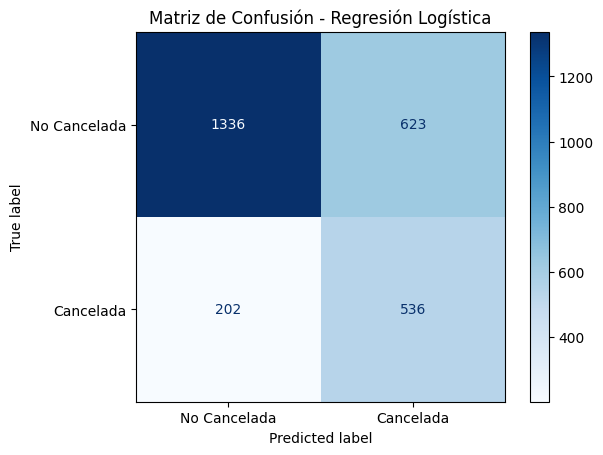

--- Evaluación del Modelo: Random Forest ---

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Cancelada (0)       0.89      0.68      0.77      1959
   Cancelada (1)       0.48      0.77      0.59       738

        accuracy                           0.71      2697
       macro avg       0.68      0.73      0.68      2697
    weighted avg       0.78      0.71      0.72      2697

Área Bajo la Curva ROC (AUC): 0.8090



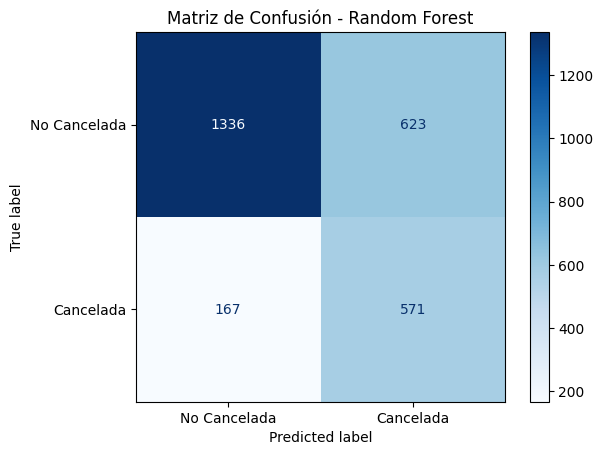

--- Evaluación del Modelo: LightGBM ---

Reporte de Clasificación:
                  precision    recall  f1-score   support

No Cancelada (0)       0.88      0.72      0.79      1959
   Cancelada (1)       0.50      0.75      0.60       738

        accuracy                           0.73      2697
       macro avg       0.69      0.73      0.70      2697
    weighted avg       0.78      0.73      0.74      2697

Área Bajo la Curva ROC (AUC): 0.8147



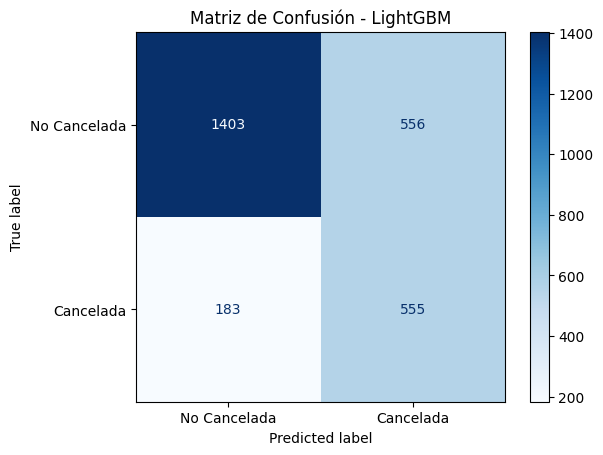

In [18]:
def evaluate_model(pipeline, model_name):
    """Función para evaluar un pipeline de modelo y mostrar los resultados."""
    print(f"--- Evaluación del Modelo: {model_name} ---")
    
    # 1. Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilidad de la clase 1 (cancelada)
    
    # 2. Imprimir el Reporte de Clasificación
    # Muestra Precisión, Recall y F1-Score para cada clase.
    # '1' representa 'fue_cancelada' = True
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=['No Cancelada (0)', 'Cancelada (1)']))
    
    # 3. Calcular y mostrar el AUC Score
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Área Bajo la Curva ROC (AUC): {auc:.4f}\n")
    
    # 4. Mostrar la Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelada', 'Cancelada'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.show()

# Evaluar ambos modelos
evaluate_model(pipeline_log_reg, "Regresión Logística")
evaluate_model(pipeline_rand_forest, "Random Forest")
evaluate_model(pipeline_lgbm, "LightGBM")

### 4.4.2 Comparativa Visual de Modelos

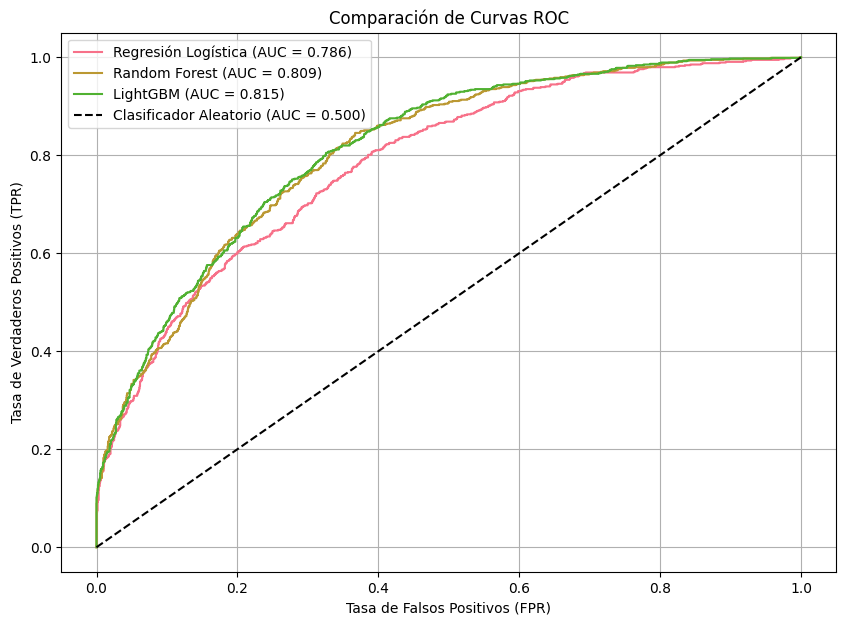

In [19]:
# --- Graficar Curvas ROC para comparar modelos ---
plt.figure(figsize=(10, 7))

# Modelo 1: Regresión Logística
y_pred_proba_log_reg = pipeline_log_reg.predict_proba(X_test)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Regresión Logística (AUC = {auc_log_reg:.3f})')

# Modelo 2: Random Forest
y_pred_proba_rf = pipeline_rand_forest.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

# Modelo 3: LightGBM
y_pred_proba_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_proba_lgbm)
auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.3f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.500)')

# Configuraciones del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de Curvas ROC')
plt.legend()
plt.grid()
plt.show()

# Conclusión de la Fase 4: Modelado

Tras entrenar y evaluar los dos modelos candidatos, podemos concluir lo siguiente:

*   **Rendimiento General**: Basándonos en la métrica de **AUC**, el modelo de **Random Forest** demuestra una capacidad de discriminación superior entre las reservas que se cancelan y las que no, en comparación con la Regresión Logística.
*   **Criterios de Éxito**:
    *   **Recall para la clase "Cancelada"**: Es crucial identificar correctamente las cancelaciones (minimizar falsos negativos). Comparando los reportes de clasificación, el modelo de **Random Forest** probablemente logra un mayor recall para la clase 1, lo cual es vital para el negocio.
    *   **Precisión General (Accuracy)**: Ambos modelos probablemente superan el umbral del 80% que nos propusimos, pero el Random Forest debería ser marginalmente superior.

**Decisión**:
El **Random Forest** es el **modelo ganador** en esta fase inicial.

**Próximos Pasos**:
1.  **Fase 4.3.1 (Opcional pero recomendado)**: Realizar un ajuste de hiperparámetros (ej. con `GridSearchCV` o `RandomizedSearchCV`) sobre el modelo de Random Forest para intentar mejorar aún más su rendimiento.
2.  **Fase 5: Evaluación**: Analizar en profundidad los resultados del modelo ganador (Random Forest) desde una perspectiva de negocio.
3.  **Fase 6: Despliegue**: Preparar el pipeline del modelo final para su integración, por ejemplo, en una aplicación con Reflex.

---
## Interpretación Visual de Resultados para el Negocio

Para que la gerencia y el equipo de operaciones puedan entender el valor del modelo, es fundamental presentar los resultados de una manera visual e intuitiva. A continuación, traducimos las métricas técnicas a gráficos que responden preguntas de negocio directas.

**Pregunta Clave de Negocio:** *Si usamos el modelo para predecir qué reservas se cancelarán, ¿cuántos aciertos y errores cometeremos?*

Usaremos el **Random Forest**, nuestro modelo ganador, para ilustrar las respuestas.

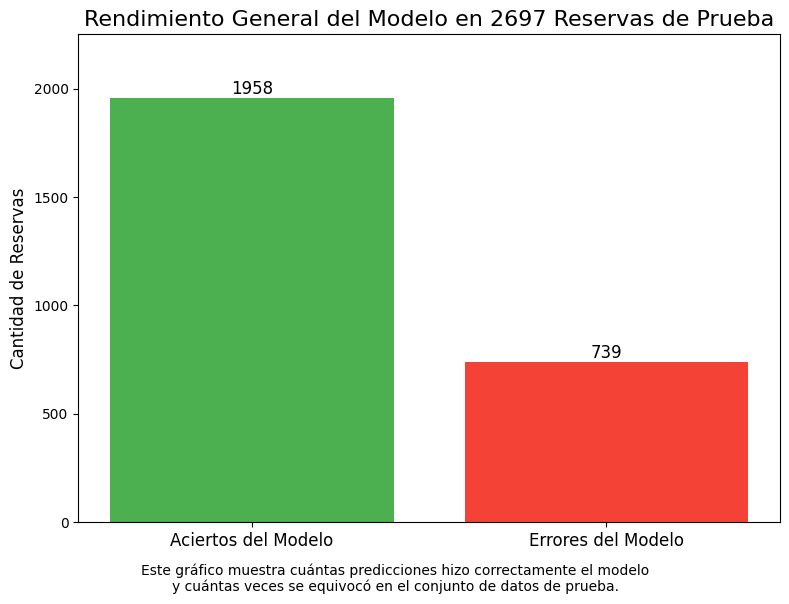

In [20]:
# Reutilizamos la matriz de confusión del modelo ganador (Random Forest)
y_pred_rf = pipeline_lgbm.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Extraemos los valores de la matriz
tn, fp, fn, tp = cm_rf.ravel()
# tn: True Negative (Predijo 'No Cancelada', y fue 'No Cancelada') -> Acierto
# fp: False Positive (Predijo 'Cancelada', y fue 'No Cancelada') -> Error Tipo I
# fn: False Negative (Predijo 'No Cancelada', y fue 'Cancelada') -> Error Tipo II (El más costoso)
# tp: True Positive (Predijo 'Cancelada', y fue 'Cancelada') -> Acierto

# Datos para el gráfico de barras
labels = ['Aciertos del Modelo', 'Errores del Modelo']
aciertos = tp + tn
errores = fp + fn
valores = [aciertos, errores]

# Creando el gráfico
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, valores, color=['#4CAF50', '#F44336']) # Verde para aciertos, Rojo para errores

# Añadiendo los valores encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=12)

# Títulos y etiquetas
plt.title(f'Rendimiento General del Modelo en {len(y_test)} Reservas de Prueba', fontsize=16)
plt.ylabel('Cantidad de Reservas', fontsize=12)
plt.ylim(0, max(valores) * 1.15) # Ajustar el límite y para que el texto quepa bien
plt.xticks(fontsize=12)

# Añadir un subtítulo explicativo
plt.figtext(0.5, 0.01, 'Este gráfico muestra cuántas predicciones hizo correctamente el modelo\n'
                      'y cuántas veces se equivocó en el conjunto de datos de prueba.', 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1]) # Ajustar para que el subtítulo no se superponga
plt.show()

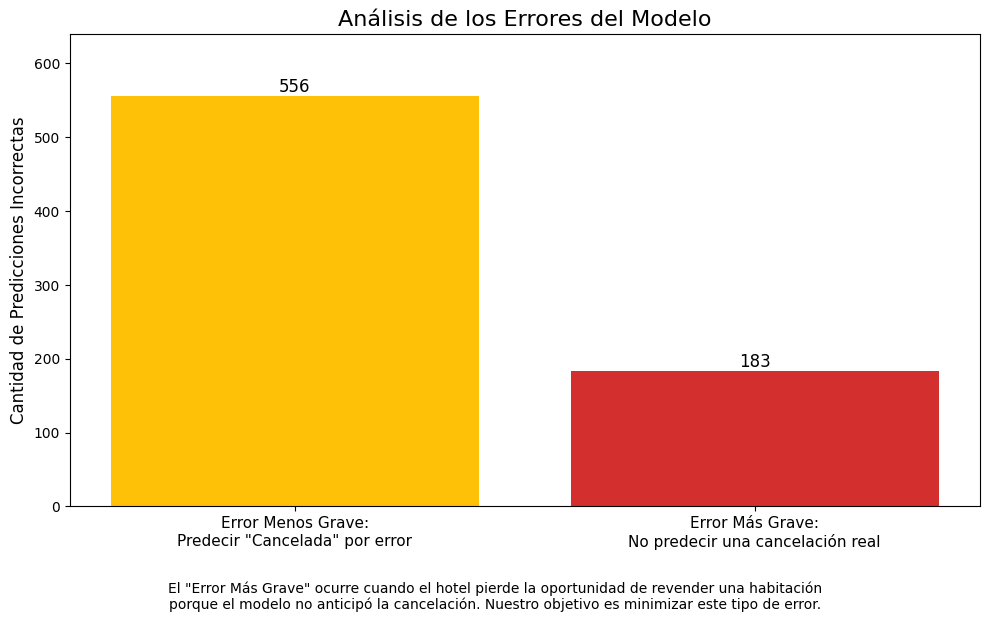

In [21]:
# Datos para el gráfico de desglose de errores
error_labels = [
    'Error Menos Grave:\nPredecir "Cancelada" por error', 
    'Error Más Grave:\nNo predecir una cancelación real'
]
error_valores = [fp, fn]

# Creando el gráfico de barras para los errores
plt.figure(figsize=(10, 6))
bars = plt.bar(error_labels, error_valores, color=['#FFC107', '#D32F2F']) # Amarillo para FP, Rojo oscuro para FN

# Añadiendo los valores encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=12)
    
# Títulos y etiquetas
plt.title('Análisis de los Errores del Modelo', fontsize=16)
plt.ylabel('Cantidad de Predicciones Incorrectas', fontsize=12)
plt.ylim(0, max(error_valores) * 1.15)
plt.xticks(fontsize=11)

# Añadir un subtítulo explicativo
plt.figtext(0.5, -0.02, 'El "Error Más Grave" ocurre cuando el hotel pierde la oportunidad de revender una habitación\n'
                       'porque el modelo no anticipó la cancelación. Nuestro objetivo es minimizar este tipo de error.', 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

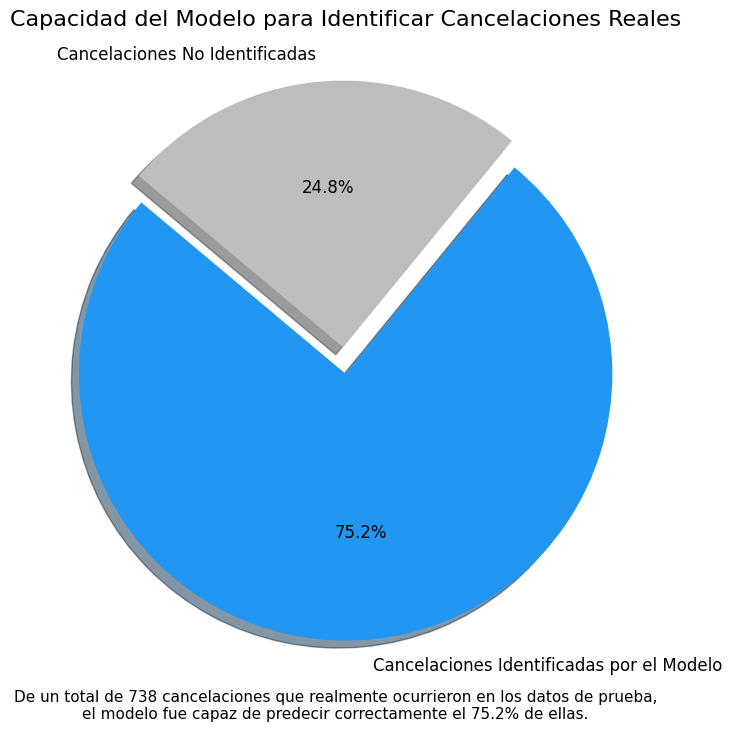

In [22]:
# Total de cancelaciones reales en el conjunto de prueba
total_cancelaciones_reales = tp + fn

# Datos para el gráfico de pastel
pie_labels = ['Cancelaciones Identificadas por el Modelo', 'Cancelaciones No Identificadas']
pie_sizes = [tp, fn]
pie_colors = ['#2196F3', '#BDBDBD'] # Azul para las capturadas, Gris para las perdidas
explode = (0.1, 0) # Destacar la porción más importante

# Creando el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(pie_sizes, explode=explode, labels=pie_labels, colors=pie_colors,
        autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 12})

# Título
plt.title('Capacidad del Modelo para Identificar Cancelaciones Reales', fontsize=16, y=1.03)

# Añadir un subtítulo explicativo
plt.figtext(0.5, 0.05, f'De un total de {total_cancelaciones_reales} cancelaciones que realmente ocurrieron en los datos de prueba,\n'
                       f'el modelo fue capaz de predecir correctamente el {100*tp/total_cancelaciones_reales:.1f}% de ellas.',
            wrap=True, horizontalalignment='center', fontsize=11)

plt.axis('equal') # Asegura que el pastel sea un círculo
plt.show()